In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('liver_patient_dataset.csv')
print("Rows, columns", df.shape)
print("\nTarget variable distribution:")
print(df['Selector'].value_counts())

Rows, columns (583, 11)

Target variable distribution:
Selector
Liver Disease       416
No Liver Disease    167
Name: count, dtype: int64


# Liver Disease Prediction

The Problem is given blood results (TB, DB, Alkphos, Sgpt, Sgot, TP, ALB, A/G Ratio) and patient demographics (Age, Gender), 
can we predict whether a patient has liver disease?

# Business value
None-invasive screening to prioritize high-risk patients for confirmatory testing, reducing unnecessary procedures and costs.

In [4]:
# missing values
print("Missing values per column:")
print(df.isnull().sum())

# A/G Ratio specifically with '?' in data
print("\nUnique values in A/G Ratio (first 10):")
print(df['A/G Ratio'].unique()[:10])

Missing values per column:
Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

Unique values in A/G Ratio (first 10):
[0.9  0.74 0.89 1.   0.4  1.3  1.1  1.2  0.8  0.6 ]


In [5]:
# Coverting A/G Ratio from string to numbers to handle '?' automatically
df['A/G Ratio'] = pd.to_numeric(df['A/G Ratio'], errors='coerce')

# Check how many NaN missing
print(f"Missing values in A/G Ratio after conversion: {df['A/G Ratio'].isnull().sum()}")

Missing values in A/G Ratio after conversion: 0


In [9]:
# Full missing count
print("Missing values per column:")
print(df.isnull().sum())

# Show rows with missing value
print("\nSample rows with missing data:")
print(df[df.isnull().any(axis=1)].head())

Missing values per column:
Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

Sample rows with missing data:
Empty DataFrame
Columns: [Age, Gender, TB, DB, Alkphos, Sgpt, Sgot, TP, ALB, A/G Ratio, Selector]
Index: []


In [11]:
# Keep essential columns present
essential_cols = ['TB', 'DB', 'Alkphos', 'Selector']
df_clean = df.dropna(subset=essential_cols)

# Drop rows of A/G Ratio is missing
df_clean = df_clean.dropna(subset=['A/G Ratio'])

print(f"Original rows: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df_clean)}")

Original rows: 583
Rows after cleaning: 583
Rows removed: 583


In [12]:
 # Check unique values in Selector
print("Unique values:", df_clean['Selector'].unique())

# Convert to binary
df_clean['target'] = (df_clean['Selector'] == 'Liver Disease').astype(int)

print("\nTarget distribution:")
print(df_clean['target'].value_counts())
print(f"nPercentage with liver disease: {df_clean['target'].mean()*100:.1f}%")

Unique values: ['Liver Disease' 'No Liver Disease']

Target distribution:
target
1    416
0    167
Name: count, dtype: int64
nPercentage with liver disease: 71.4%


In [13]:
df_clean.to_csv('liver_clean.csv', index=False)
print("Saved to liver_clean.csv")

Saved to liver_clean.csv


## Data Cleaning Complete

Converted A/G Ratio to numeric (handled '?' entries)
Removed rows missing critical values (TB, DB, Alkphos, Selector, A/G Ratio)
Created binary target column (1 = Liver Disease)
Saved clean dataset as 'liver_clean.csv'

Remaining rows: 583

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
# Defining Features (X) and target (y)
feature_cols = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB']
X = df_clean[feature_cols]
y = df_clean['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFirst S feature rows:")
print(X.head())

Features shape: (583, 7)
Target shape: (583,)

First S feature rows:
     TB   DB  Alkphos  Sgpt  Sgot   TP  ALB
0   0.7  0.1      187    16    18  6.8  3.3
1  10.9  5.5      699    64   100  7.5  3.2
2   7.3  4.1      490    60    68  7.0  3.3
3   1.0  0.4      182    14    20  6.8  3.4
4   3.9  2.0      195    27    59  7.3  2.4


In [18]:
# 80% train, 20% test, random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

Training set: 466 rows
Test set: 117 rows

Training target distribution:
target
1    0.706009
0    0.293991
Name: proportion, dtype: float64


In [20]:
# Random forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [21]:
# Prediction on test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report with precision, recall, fit
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Liver Disease']))

Accuracy: 0.692

Confusion Matrix:
[[ 9 21]
 [15 72]]

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.38      0.30      0.33        30
Liver Disease       0.77      0.83      0.80        87

     accuracy                           0.69       117
    macro avg       0.57      0.56      0.57       117
 weighted avg       0.67      0.69      0.68       117



## Baseline Model Results

**Model:** Random Forest (100 trees, default settings)
**Features:** TB, DB, Alkphos, 'Sgpt, Sgot, TP, ALB

**Accuracy:** 0.692

**What this means:**
The model correctly predicts liver disease vs no disease about accuracy of the time
Baseline performmance without any tuning

We need to use the result to investigate which features matter  most

In [23]:
# Features importance from trained model
importance_df = pd.DataFrame({
    'features': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

  features  importance
2  Alkphos    0.184172
4     Sgot    0.170081
3     Sgpt    0.167406
6      ALB    0.131465
0       TB    0.124916
5       TP    0.118815
1       DB    0.103145


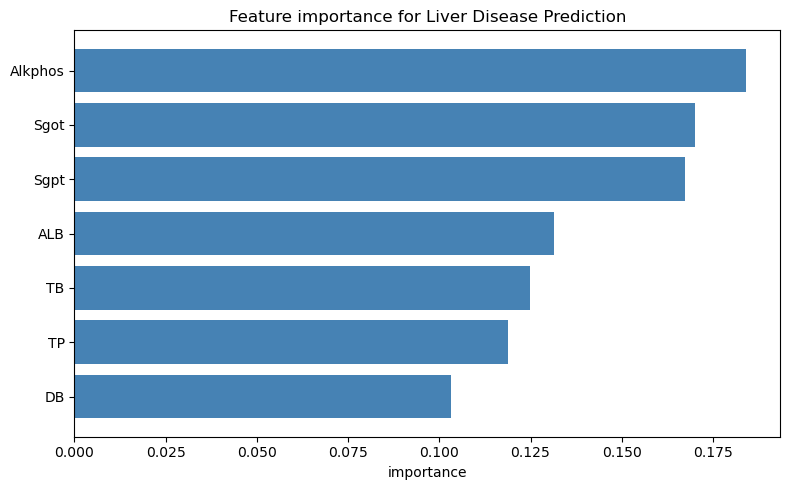

In [26]:
import matplotlib.pyplot as plt

# Bar chart visualization
plt.figure(figsize=(8, 5))
plt.barh(importance_df['features'], importance_df['importance'], color='steelblue')
plt.xlabel('importance')
plt.title("Feature importance for Liver Disease Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Finding: Which blood tests matter most?

**Top predictor:** Alkphos
**Second:** Sgot

**What this means clinically:**
Liver enzyme levels (Alkphos, Sgpt, and Sgot) are the strongest drivers in this model. This suggests that for this liver dataset,
markers of bile duct health and liver cell inflammative than bilirubin levels.

**Why this matters for a non-technical audience:**
If you're screening for liver disease based on this model's logic, the enzyme panel (Alkphos, Sgpt, Sgot) is the most critical.
Bilirubin tests (TB/DB) provides less predictive value for this particular group of patients.

**Limitation I'm aware of:**
This is correlation, not causation. The model's reliance on these specific enzymes may be unique to this dataset and hasn't been
validated on external data.

## Conclusion & Steps

**What I built:**
A random forest classifier to predict liver disease from 7 routine blood test values

**What I found:**
Baseline accuracy: 69.2% on hold out  test data
Most importance features: Alkphos and Sgot
The dataset is imbalanced 71% liver disease which affects interpretability of raw accuracy

**If this were a real business project:**
1. Collect more "No Liver Disease" samples to balance the data
2. Validate on data from a different hospital before deployment
3. Convert to a simple risk score for clinical use

**What I'd do differently with more time:**
Test logistic regression in doctors
Handle outliers in bilirubin values that look extreme in raw data